In [ ]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
pd.set_option('display.max_columns', 100)
sns.set_style(style='ticks')

#NOTE: Do prescriptive statistics? machine learning for predictive statistics? descriptive? GO ALL OUT REM!!!!
#Also consider building linear or logistic regression for this project!!

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
# Project goals:
# Project Goal Main Idea: Focus on demographics and analysis with goal of service improvement to increaser our customer base and slight retaining of customer base
#                         Since our customer churn is with in the normal range, we don't have to prioritize saving customers.
    # try to visualize that some of the customers are still in DSL, suggest movement
    # to make them switch to fiber optic since it is much better than DSL (since customer might churn because of the internet speed)
    # (Also check if the customer churnings internet service is DSL.)
    # Also, this is good for the company's revenue/income.

    # 


In [4]:
df.info()
#TotalCharges should have int/float value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning part starts here:

In [5]:
categories = df.columns.to_list()
for i in categories:
    print('the unique values for', i, ' are:\n',df[i].unique(),'\n')

the unique values for customerID  are:
 ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] 

the unique values for gender  are:
 ['Female' 'Male'] 

the unique values for SeniorCitizen  are:
 [0 1] 

the unique values for Partner  are:
 ['Yes' 'No'] 

the unique values for Dependents  are:
 ['No' 'Yes'] 

the unique values for tenure  are:
 [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] 

the unique values for PhoneService  are:
 ['No' 'Yes'] 

the unique values for MultipleLines  are:
 ['No phone service' 'No' 'Yes'] 

the unique values for InternetService  are:
 ['DSL' 'Fiber optic' 'No'] 

the unique values for OnlineSecurity  are:
 ['No' 'Yes' 'No internet service'] 

the unique values for OnlineBackup  are:
 ['Yes' 'No' 'No internet service'] 

the unique values for DeviceP

In [6]:
#rename columns customerID, tenure, and gender for more consistent naming:
df = df.rename(columns={'customerID': 'CustomerID', 'gender':'Gender', 'tenure':'Tenure'})

In [7]:
##Cleaning TotalCharges column:
df['TotalChargesCleaned'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
##check for null values
df['TotalChargesCleaned'].isna().sum()
##There are 11 null values. Observe these null values.

11

In [8]:
#Comparing the null values to the original column
df[df['TotalChargesCleaned'].isnull()][['TotalCharges','TotalChargesCleaned']]
#Why these TotalCharges are blank instead of null? Check the Tenure and MonthlyCharges columns

,TotalCharges,TotalChargesCleaned
488,,NaN
753,,NaN
936,,NaN
1082,,NaN
1340,,NaN
3331,,NaN
3826,,NaN
4380,,NaN
5218,,NaN
6670,,NaN


In [9]:
#drop duplicates
df = df.drop_duplicates()

In [10]:
df[['Tenure', 'MonthlyCharges', 'TotalCharges', 'TotalChargesCleaned']].query('TotalChargesCleaned.isnull()')
#As can be observed, all of these has 0 tenureship. Hence TotalCharges should be 0.

,Tenure,MonthlyCharges,TotalCharges,TotalChargesCleaned
488,0,52.55,,NaN
753,0,20.25,,NaN
936,0,80.85,,NaN
1082,0,25.75,,NaN
1340,0,56.05,,NaN
3331,0,19.85,,NaN
3826,0,25.35,,NaN
4380,0,20.00,,NaN
5218,0,19.70,,NaN
6670,0,73.35,,NaN


In [11]:
#Replacing TotalChargesCleaned null values with 0's:
df['TotalChargesCleaned'] = df['TotalChargesCleaned'].fillna(0)

In [12]:
#Inspect data info again:
df.info()
#Note: We could remove TotalCharges column for efficiency, but since this is not a big dataset, it won't matter that much.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           7043 non-null   object 
 1   Gender               7043 non-null   object 
 2   SeniorCitizen        7043 non-null   int64  
 3   Partner              7043 non-null   object 
 4   Dependents           7043 non-null   object 
 5   Tenure               7043 non-null   int64  
 6   PhoneService         7043 non-null   object 
 7   MultipleLines        7043 non-null   object 
 8   InternetService      7043 non-null   object 
 9   OnlineSecurity       7043 non-null   object 
 10  OnlineBackup         7043 non-null   object 
 11  DeviceProtection     7043 non-null   object 
 12  TechSupport          7043 non-null   object 
 13  StreamingTV          7043 non-null   object 
 14  StreamingMovies      7043 non-null   object 
 15  Contract             7043 non-null   o

# Data understanding part starts here:

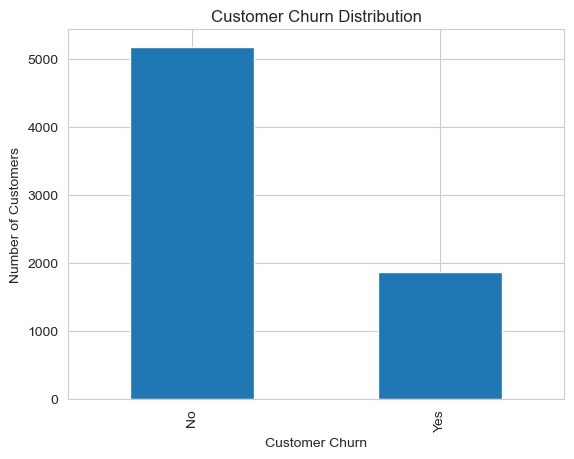

In [13]:
#Check how many customers churns or not in this dataset:

df['Churn'].value_counts().plot(kind='bar', title='Customer Churn Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('Customer Churn')
plt.show()

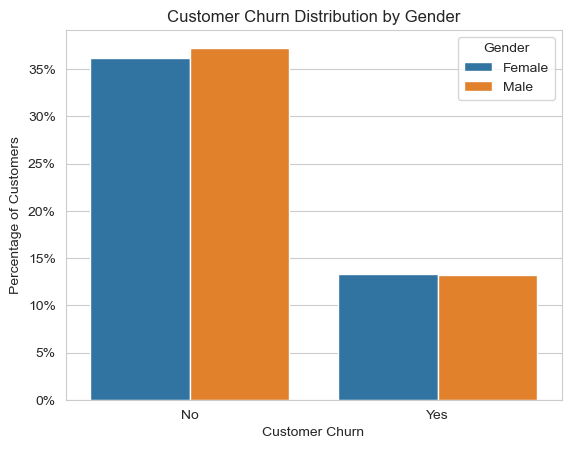

In [14]:
#let's dive deeper by getting the count based on the gender

df_gender_churn = df.groupby('Gender')['Churn'].value_counts().reset_index()
df_gender_churn['total'] = df_gender_churn['count'].sum()
df_gender_churn['percent'] = 100 * df_gender_churn['count'] / df_gender_churn['total']

sns.set_style('whitegrid')
sns.barplot(data=df_gender_churn, y='percent', x='Churn', hue='Gender')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x)}%'))
plt.title('Customer Churn Distribution by Gender')
plt.ylabel('Percentage of Customers')
plt.xlabel('Customer Churn')
plt.show()
#gender seeems not to play role in customer churn.
#confirm this using hypothesis testing.

In [ ]:
# Hypothesis testing: Chi-square for test of independence
# Assumptions are met: Both are categorical variables, mutually exclusive and independent, each categories are of have at least frequency of 5
# Null Hypothesis: The two variables are independent of each other.
# Alternative Hypothesis: The two variables are dependent on each other.


g_chi_table = pd.crosstab(df['Gender'], df['Churn'])
print('Contingency Table:\n', g_chi_table)

chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(g_chi_table)

print(f'\nChi-square statistic: {chi2_statistic}')
print(f'P-value: {p_value}')
print(f'Degrees of freedom: {degrees_of_freedom}')
print(f'Expected frequencies:\n {expected_frequencies}')

# Since p-value > 0.05, we fail to reject the null hypothesis. 
# Hence, there is no enough proof to show that Gender has significant relationship with customer churn.

Contingency Table:
 Churn     No  Yes
Gender           
Female  2549  939
Male    2625  930

Chi-square statistic: 0.4840828822091383
P-value: 0.48657873605618596
Degrees of freedom: 1
Expected frequencies:
 [[2562.38989067  925.61010933]
 [2611.61010933  943.38989067]]


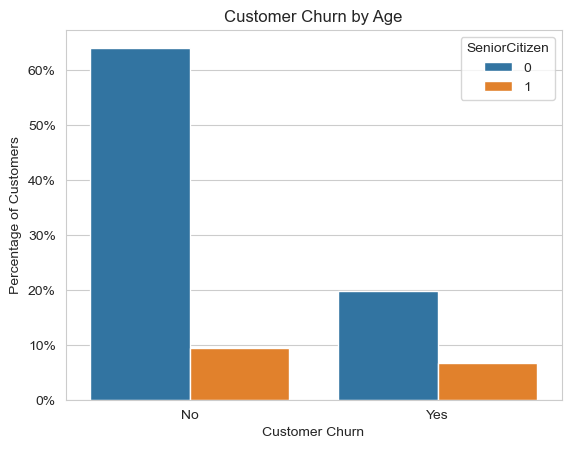

In [33]:
# Let's dive deeper by getting the count based on the SeniorCitizen column

df_sc_churn = df.groupby('SeniorCitizen')['Churn'].value_counts().reset_index()
df_sc_churn['total'] = df_sc_churn['count'].sum()
df_sc_churn['percent'] = 100 * df_sc_churn['count'] / df_sc_churn['total']

sns.barplot(data=df_sc_churn, y='percent', x='Churn', hue='SeniorCitizen')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x)}%'))
plt.title('Customer Churn by Age')
plt.ylabel('Percentage of Customers')
plt.xlabel('Customer Churn')
plt.show()

# SeniorCitizen column seems to have significant relationship to customer churn.
# Let's confirm this using Chi-Square test for independence.

In [34]:
#REMINDER: BEFORE USING ANY STATISTICAL ANALYSIS, MAKE SURE TO CHECK IF THE ASSUMPTIONS ARE MET. IF ASSUMPTIONS ARE NOT MET, MAKE SURE TO TAKE NOTE OF THIS
#If performing chi-square test for independence for continuous variables, make sure to categorize them.


#Chi-square test for independence
#First, before using the test, let's check if the assumptions are met:

#TRY TO INCORPORATE YUNG 7-STEP FOR STATISTICAL ANALYSIS NI SIR USONA RITO.

#1.) Categorical data
#...

#Since the assumptions are met, we can use chi-square test of independence for testing the correlation.

#from scipy.stats import chi2_contingency
sc_chi_table = pd.crosstab(df['SeniorCitizen'], df['Churn'])
print('Contingency Table:\n', sc_chi_table)

chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(sc_chi_table)

print(f'\nChi-square statistic: {chi2_statistic}')
print(f'P-value: {p_value}')
print(f'Degrees of freedom: {degrees_of_freedom}')
print(f'Expected frequencies:\n {expected_frequencies}')

# By Chi-square test for independence, we say that there is a significant relationship between column SeniorCitizen and customer churn.
# SeniorCitizen column definitely a factor affecting customer churn.

Contingency Table:
 Churn            No   Yes
SeniorCitizen            
0              4508  1393
1               666   476

Chi-square statistic: 159.42630036838742
P-value: 1.510066805092378e-36
Degrees of freedom: 1
Expected frequencies:
 [[4335.05239245 1565.94760755]
 [ 838.94760755  303.05239245]]


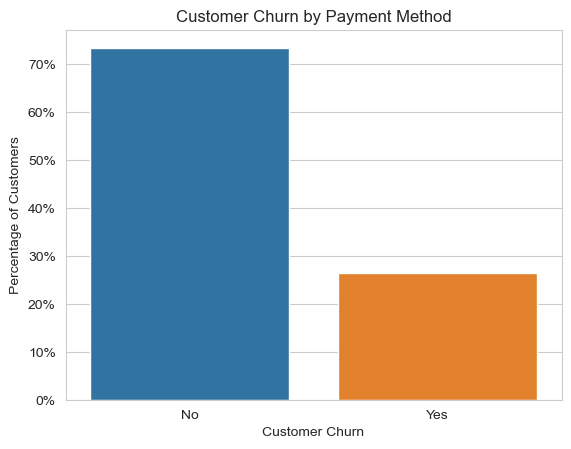

In [35]:
df_pm_churn = df.groupby('PaymentMethod')['Churn'].value_counts().reset_index()
df_pm_churn['percent'] = 100 * df_pm_churn['count']/df_pm_churn['count'].sum()
df_pm_churn = df_pm_churn.groupby('Churn')[['percent']].sum()

sns.barplot(data=df_pm_churn, y='percent', x='Churn', hue='Churn', errorbar=None)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'{int(x)}%'))
plt.title('Customer Churn by Payment Method')
plt.ylabel('Percentage of Customers')
plt.xlabel('Customer Churn')
plt.show()

#Bar graph expresses that payment method most likely affects customer churn.

In [36]:
#Chi-square test for independence

pm_chi_table = pd.crosstab(df['PaymentMethod'], df['Churn'])
print('Contingency Table:\n', pm_chi_table)

chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(pm_chi_table)

print(f'\nChi-square statistic: {chi2_statistic}')
print(f'P-value: {p_value}')
print(f'Degrees of freedom: {degrees_of_freedom}')
print(f'Expected frequencies:\n {expected_frequencies}')

#PaymentMethod is definitely a factor for customer churn.

Contingency Table:
 Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308

Chi-square statistic: 648.1423274814
P-value: 3.6823546520097993e-140
Degrees of freedom: 3
Expected frequencies:
 [[1134.26891949  409.73108051]
 [1118.10705665  403.89294335]
 [1737.40025557  627.59974443]
 [1184.22376828  427.77623172]]


In [37]:
df.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TotalChargesCleaned'],
      dtype='object')

In [38]:
#Test other factors for customer churn
contingency_table = pd.crosstab(df['PaymentMethod'], df['Churn'])
print('Contingency Table:\n', contingency_table)

chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)

print(f'\nChi-square statistic: {chi2_statistic}')
print(f'P-value: {p_value}')
print(f'Degrees of freedom: {degrees_of_freedom}')
print(f'Expected frequencies:\n {expected_frequencies}')

Contingency Table:
 Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308

Chi-square statistic: 648.1423274814
P-value: 3.6823546520097993e-140
Degrees of freedom: 3
Expected frequencies:
 [[1134.26891949  409.73108051]
 [1118.10705665  403.89294335]
 [1737.40025557  627.59974443]
 [1184.22376828  427.77623172]]


In [39]:
predictors = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']
for X in predictors:
    contingency_table = pd.crosstab(df[X], df['Churn'])
    chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)
    
    print('-----------------------')
    print(f'Chi-square test for independence for {X}')
    print(f'\nChi-square statistic: {chi2_statistic}')
    print(f'P-value: {p_value}')
    print(f'Degrees of freedom: {degrees_of_freedom}')
    print(f'Expected frequencies:\n {expected_frequencies}')

-----------------------
Chi-square test for independence for Gender

Chi-square statistic: 0.4840828822091383
P-value: 0.48657873605618596
Degrees of freedom: 1
Expected frequencies:
 [[2562.38989067  925.61010933]
 [2611.61010933  943.38989067]]
-----------------------
Chi-square test for independence for SeniorCitizen

Chi-square statistic: 159.42630036838742
P-value: 1.510066805092378e-36
Degrees of freedom: 1
Expected frequencies:
 [[4335.05239245 1565.94760755]
 [ 838.94760755  303.05239245]]
-----------------------
Chi-square test for independence for Partner

Chi-square statistic: 158.7333820309922
P-value: 2.1399113440759935e-36
Degrees of freedom: 1
Expected frequencies:
 [[2674.78830044  966.21169956]
 [2499.21169956  902.78830044]]
-----------------------
Chi-square test for independence for Dependents

Chi-square statistic: 189.12924940423474
P-value: 4.9249216612154196e-43
Degrees of freedom: 1
Expected frequencies:
 [[3623.93042737 1309.06957263]
 [1550.06957263  559.9304

In [40]:
#Explore the characteristics of customers who churned.
df_churned = df[df['Churn'] == 'Yes'].copy()

df_not_churned = df[df['Churn'] == 'No'].copy() # copy of dataset with customer not churning only

In [41]:
#Number of Senior Citizen Customers who churned:

df_churned.groupby('SeniorCitizen').size()

SeniorCitizen
0    1393
1     476
dtype: int64

In [42]:
##SCRATCH
df_churned['Churn'] = df_churned['Churn'].map({'Yes':1, 'No':0})

<Axes: xlabel='InternetService'>

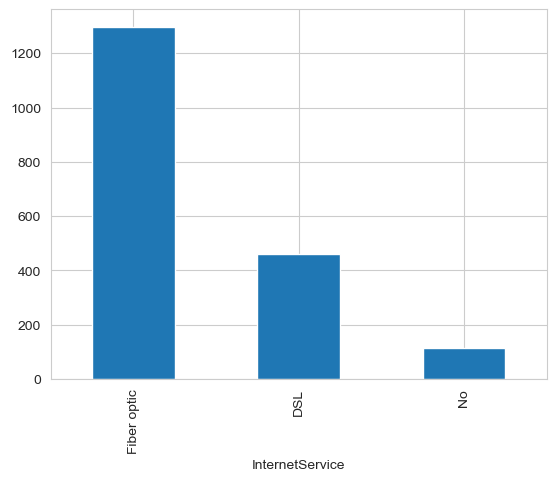

In [43]:
# Check the numbers of customer churns per InternetService

df_churned['InternetService'].value_counts().plot(kind='bar')


# Use InternetService as pivot for this analysis

# Find out why does many Fiber optic customers churned (suspiciously high since Fiber Optic is much better than DSL at all scales.)
# This might be because of the monthly charges. Compare the price of Fiber optic to DSL to see if Fiber optic is OP or DSL is price is just too low.
# check the percentage of Fiber optic churners relative to the total number of Fiber optic customers.

In [44]:
# Exploratory data analysis for factors affecting InternetService



In [45]:
# Looking for factors affecting customer's choice of InternetService
columns = df.drop(columns=['Churn', 'InternetService']).columns

chi_scores = pd.DataFrame(columns=['IndependentVariable','chi_statistic', 'p_value'],
                          index=range(len(columns)))
for i,col in enumerate(columns):
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)
    chi_scores.loc[i, 'IndependentVariable'] = col
    chi_scores.loc[i, 'chi_statistic'] = chi2_statistic
    chi_scores.loc[i, 'p_value'] = p_value
chi_scores.sort_values(by='chi_statistic', ascending=False)

,IndependentVariable,chi_statistic,p_value
0,CustomerID,7043.0,0.494398
18,TotalCharges,6514.047813,0.553246
19,TotalChargesCleaned,6514.047813,0.553246
17,MonthlyCharges,2123.60913,0.0
14,Contract,1184.596572,0.0
5,Tenure,1065.330857,0.0
8,OnlineSecurity,849.998968,0.0
11,TechSupport,828.197068,0.0
16,PaymentMethod,648.142327,0.0
9,OnlineBackup,601.81279,0.0


In [46]:
df_churned[df_churned['InternetService'] == 'Fiber optic'].describe()

# As per checking, there not much of a difference in monthlycharges.

,SeniorCitizen,Tenure,MonthlyCharges,Churn,TotalChargesCleaned
count,1297.000000,1297.000000,1297.000000,1297.0,1297.000000
mean,0.303007,20.196608,88.126484,1.0,1914.616384
std,0.459735,20.067649,11.882834,0.0,2046.711293
min,0.000000,1.000000,67.750000,1.0,68.500000
25%,0.000000,3.000000,78.800000,1.0,273.750000
50%,0.000000,13.000000,87.550000,1.0,1111.650000
75%,1.000000,33.000000,98.400000,1.0,2952.850000
max,1.000000,72.000000,118.350000,1.0,8684.800000


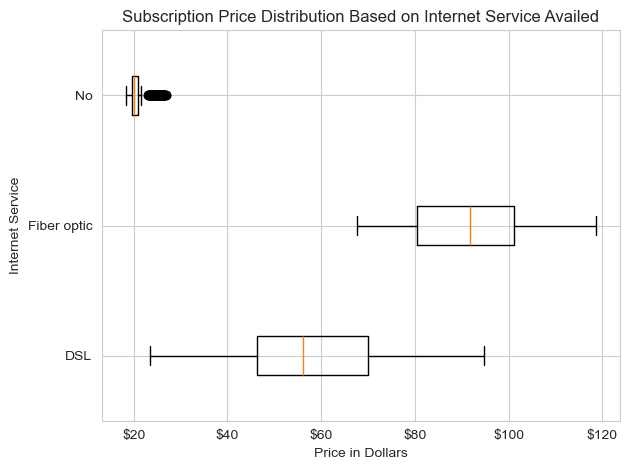

In [47]:
services = ['DSL', 'Fiber optic', 'No']
df_list = [df[df['InternetService'] == service]['MonthlyCharges'] for service in services]
plt.boxplot(data=df_list, x=df_list, tick_labels=services, vert=False)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x)}'))
plt.title('Subscription Price Distribution Based on Internet Service Availed')
plt.xlabel('Price in Dollars')
plt.ylabel('Internet Service')
plt.tight_layout()
plt.show()

# As observed, Fiber optic and DSL subscribers seems to be paying the normal amount (comparative to the company).
# Interestingly, many of non-internet subscriber paying more than usual set by the company.
# In my opinion, this is one of the reasons why subscribers in this category churns.

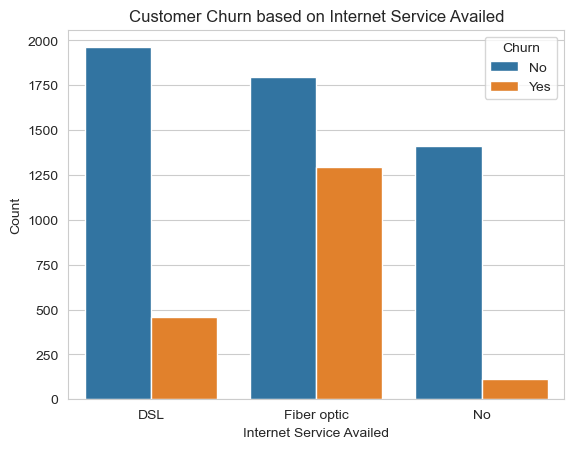

In [48]:
# get customer churn based on internet service

df_InternetService = df.groupby(['InternetService', 'Churn'])['Churn'].value_counts()
df_InternetService = df_InternetService.reset_index()
sns.barplot(data=df_InternetService, x='InternetService', y='count', hue='Churn', errorbar=None)
plt.title('Customer Churn based on Internet Service Availed')
plt.xlabel('Internet Service Availed')
plt.ylabel('Count')
plt.show()

# Interestingly, customers who do not avail internet service has the lowest churn of all even many of them paying more than the average.
# Find the reason behind this (if possible)

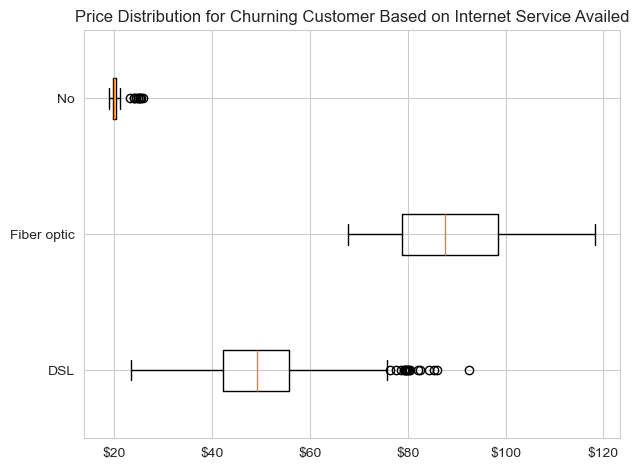

In [53]:
services = ['DSL', 'Fiber optic', 'No']
df_churn_list = [df_churned[df_churned['InternetService'] == service]['MonthlyCharges'] for service in services]

plt.boxplot(data=df_churn_list, x=df_churn_list, tick_labels=services, vert=False)
plt.title('Price Distribution for Churning Customer Based on Internet Service Availed')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x)}'))
plt.tight_layout()
plt.show()

# As observed, many DSL subscribers are paying as much as those Fiber optic subscribers.
# Despite the low churn rate for 'No' category, many churners has above average monthly charges.
# So, price is still a huge factor for customer churn in this category.

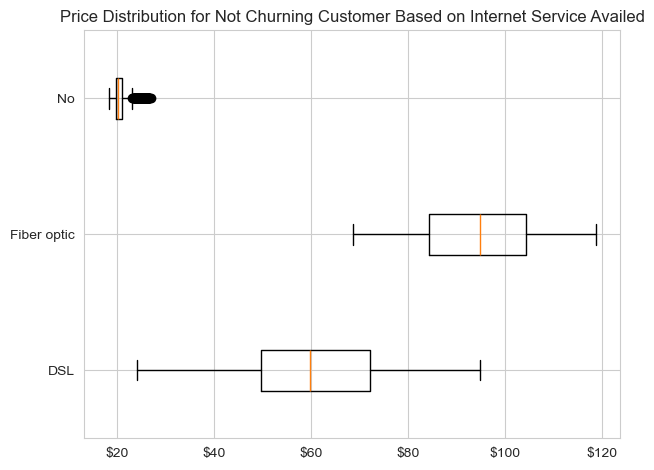

In [51]:
#Check the boxplot for those who did not churn, for comparison.
df_no_churn_list = [df_not_churned[df_not_churned['InternetService'] == service]['MonthlyCharges'] for service in services]

#plot
plt.boxplot(data=df_no_churn_list, x=df_no_churn_list, tick_labels=services, vert=False)
plt.title('Price Distribution for Not Churning Customer Based on Internet Service Availed')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x)}'))
plt.tight_layout()
plt.show()

In [52]:
# After seeing the last 3 graphs, it seems that price does not really matter for customer churn.
# More likely these graphs implies problem with the quality of service.
# This is because regardless of price, the customers still churn. (especially Fiber optic services, investigate this.)
# In fact, price distribution for customers who does not churn shows higher than those who churn which proves this point.

# As a solution, invest some time and money for process improvements..
# Maybe add a promo for the current subscribers as a temporary band-aid.
# Internally, give incentives to those who would come up with good processes ideas.

#Try to find other info such as cost of living of partnered couples, senior citizen, etc there's still chance that the problem lies with the demographics.